# Construction Safety Intelligence · Notebook 1: Data cleaning and exploration
**Author:** Atul Iwale · **Project 14** of the AEC Fieldwork portfolio · **Real, public data**

**Business question:** a safety manager receives injury reports written in free text. Which hazards cause the most serious injuries on construction sites, in which trades, and can the cause of each report be coded automatically and consistently?

**Data source:** OSHA Severe Injury Reports, January 2015 to November 2025, downloaded from the [OSHA Severe Injury Dashboard](https://www.osha.gov/severe-injury-reports) ("Download the full SIR data set", file dated 7 Aug 2026). US employers under federal OSHA must report every work-related amputation, in-patient hospitalisation or loss of an eye.

**Licence:** US federal government data. The Department of Labor states that its materials *"may be used, reproduced and distributed without permission"*. OSHA does not endorse this project.

This notebook covers loading, quality checks, cleaning, privacy steps, the cause labels, and an exploratory risk analysis. All cleaning functions live in `src/cleaning.py`, so the same code runs here and in `python src/clean.py`.

**Contents**
1. Load the raw file · 2. Keep construction only · 3. Data quality checks · 4. Tidy types and text
5. Privacy: remove employer names · 6. Cause groups from OSHA's codes · 7. Finding: OSHA changed its coding manual in January 2024
8. Exploratory risk analysis · 9. Save the clean dataset

In [1]:
import sys, json, re, warnings; warnings.filterwarnings('ignore')
sys.path.insert(0, '../src')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import cleaning as C
pd.set_option('display.width', 170); pd.set_option('display.max_colwidth', 110); pd.set_option('display.max_rows', 60)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})

## 1. Load the raw file
The raw file is not stored in this repository because it contains employer names and street addresses. Download it from the OSHA link above and unzip it into `data/raw/`. Everything is read as text first, so codes keep their leading digits and nothing is silently converted.

In [2]:
raw = C.load_raw('../data/raw/January2015toNovember2025.csv')
print(f'{len(raw):,} reports, {raw.shape[1]} columns')
miss = raw.isna().sum().to_frame('missing'); miss['missing %'] = (miss.missing / len(raw) * 100).round(1)
miss.T

105,996 reports, 28 columns


,ID,UPA,EventDate,Employer,Address1,Address2,City,State,Zip,Latitude,...,NatureTitle,Part of Body,Part of Body Title,Event,EventTitle,Source,SourceTitle,Secondary Source,Secondary Source Title,FederalState
missing,0.0,0.0,0.0,0.0,18.0,96693.0,17.0,0.0,24.0,72.0,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,55381.0,55382.0,0.0
missing %,0.0,0.0,0.0,0.0,0.0,91.2,0.0,0.0,0.0,0.1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,52.2,52.2,0.0


## 2. Keep construction only
Each report carries the employer's industry code (NAICS). Sector **23 is Construction**. A handful of reports have a shortened code (for example `2382`), which still identifies construction, so the filter uses the first two digits.

In [3]:
con = C.filter_construction(raw)
print(f'Construction: {len(con):,} of {len(raw):,} reports ({len(con)/len(raw):.1%})')
print('NAICS code lengths:', con['Primary NAICS'].str.strip().str.len().value_counts().to_dict())
con['Primary NAICS'].str[:4].map(C.TRADE_NAMES).value_counts().to_frame('reports')

Construction: 19,021 of 105,996 reports (17.9%)
NAICS code lengths: {6: 18994, 5: 18, 4: 6, 2: 2, 3: 1}


,reports
Primary NAICS,
"Foundation, structure and exterior (incl. roofing, framing, concrete, steel)",4652
"Building equipment (electrical, plumbing, HVAC)",3731
Non-residential building,2597
Utility systems,1880
"Other specialty trades (site prep, demolition)",1720
"Highway, street and bridge",1583
"Building finishing (drywall, painting, flooring)",1389
Residential building,907
Other heavy and civil,540


## 3. Data quality checks
Before cleaning, I check what could mislead a model: bad dates, duplicates, missing fields, very short narratives, and whether the cause codes are consistent.

In [4]:
dates = pd.to_datetime(con.EventDate, format='%m/%d/%Y', errors='coerce')
checks = {
    'unparseable dates': int(dates.isna().sum()),
    'date range': f'{dates.min():%d %b %Y} to {dates.max():%d %b %Y}',
    'duplicate report IDs': int(con.ID.duplicated().sum()),
    'duplicate narratives': int(con['Final Narrative'].duplicated().sum()),
    'narratives under 40 characters': int((con['Final Narrative'].str.len() < 40).sum()),
    'reports with no secondary source': int(con['Secondary Source'].isna().sum()),
    'reports with no OSHA inspection linked': int(con.Inspection.isna().sum()),
    'distinct event (cause) codes': int(con.Event.str.strip().nunique()),
}
pd.Series(checks).to_frame('value')

,value
unparseable dates,0
date range,02 Jan 2015 to 28 Nov 2025
duplicate report IDs,0
duplicate narratives,3
narratives under 40 characters,22
reports with no secondary source,8921
reports with no OSHA inspection linked,11877
distinct event (cause) codes,348


In [5]:
print('Reports per year:'); print(dates.dt.year.value_counts().sort_index().to_dict())
print('\nNarrative length (characters):'); print(con['Final Narrative'].str.len().describe().round(0).to_dict())
print('\nShortest narratives:')
for t in con['Final Narrative'][con['Final Narrative'].str.len() < 40].head(6): print(' ', repr(t))

Reports per year:
{2015: 1711, 2016: 1867, 2017: 1862, 2018: 1969, 2019: 1956, 2020: 1729, 2021: 1528, 2022: 1516, 2023: 1626, 2024: 1618, 2025: 1639}

Narrative length (characters):
{'count': 19021.0, 'mean': 210.0, 'std': 98.0, 'min': 4.0, '25%': 145.0, '50%': 191.0, '75%': 253.0, 'max': 2134.0}

Shortest narratives:
  'Employee fell through crank scaffold.'
  'Finger cut accident.'
  'Employee caught hand in system.'
  "Employee fell into an 8' manhole."
  'An employee fell from a scaffold.'
  'Fall'


The narratives vary a lot: the median is about 190 characters, but some are a few words and some run to 2,000 characters. The cause codes are the bigger problem. There are 348 distinct codes, stored with **2, 3 or 4 digits**, and the same 2-digit prefix does not always mean the same thing:

In [6]:
ev = con.assign(code=con.Event.str.strip(), title=con.EventTitle.str.strip().str.replace(r'\s+', ' ', regex=True))
print('Code lengths:', ev.code.str.len().value_counts().sort_index().to_dict())
ex = ev[ev.code.str[:2] == '41'].groupby(ev.code.str.len()).title.agg(lambda s: s.value_counts().head(2).to_dict())
print('\nMost common titles for codes starting with 41, by code length:'); print(ex.to_string())

Code lengths: {2: 399, 3: 3952, 4: 14670}

Most common titles for codes starting with 41, by code length:
code
3              {'Fall to lower level unspecified': 6, 'Slip or trip without fall, unspecified': 5}
4    {'Other fall to lower level 6 to 30 feet': 379, 'Other fall to lower level unspecified': 292}


Codes starting with `41` mean "slip or trip" in one version and "fall to lower level 6 to 30 feet" in another. So I do **not** group by code prefix. The event **title** is consistent, so the cause groups in section 6 are built from the title, and the full code-to-group table is saved for review.

## 4. Tidy types and text
Dates become real dates, the injury counts become integers, text fields are trimmed, and each report gets a readable trade name from its 4-digit NAICS group.

In [7]:
df = C.tidy(con)
df[['event_date', 'naics', 'trade', 'state', 'Hospitalized', 'Amputation', 'Loss of Eye', 'inspected', 'narrative']].head(3)

,event_date,naics,trade,state,Hospitalized,Amputation,Loss of Eye,inspected,narrative
13,2015-01-02,238110,"Foundation, structure and exterior (incl. roofing, framing, concrete, steel)",Texas,1,0,0,0,"Two employees in a scissor lift were wrecking forms, taking forms down, and removing the forms. They lost ..."
19,2015-01-02,237990,Other heavy and civil,Louisiana,1,0,0,0,"On Friday, January 2, 2015, at 10:30 p.m., a crew of employees were changing out wooden decking boards on ..."
23,2015-01-03,238990,"Other specialty trades (site prep, demolition)",Ohio,1,0,0,1,"While in the process of unloading pre-tied mats of rebar, one of the bundles fell off of the tying jig and..."


## 5. Privacy: remove employer names
The raw file names the employer and gives the street address. They are public on osha.gov, but this portfolio does not need to put company names next to injuries. So I drop the employer, address, ZIP code, coordinates and OSHA's internal ID column, and I replace the employer's own name wherever it appears inside a narrative.

In [8]:
df = C.redact_all(df)
print(f"Narratives where the employer's name was replaced: {df.employer_redacted.sum()}")
row = df[df.employer_redacted == 1].iloc[1]
print('\nAfter:', row.narrative[:260])
print('\nColumns removed before publishing:', C.PRIVATE_COLUMNS)

Narratives where the employer's name was replaced: 51

After: On or about 11 April 2015, at approximately 0830 hours, a [EMPLOYER] employee received burns on his wrist and face when flammable gasses that accumulated during a pipeline hot tap ignited. The employee was helping a welder weld the pipe sections together when 

Columns removed before publishing: ['Employer', 'Address1', 'Address2', 'Zip', 'Latitude', 'Longitude', 'UPA']


Only the reporting employer's own name is replaced. Other company names (a general contractor, a utility) can remain in a few narratives. The published data keeps state, trade and date, which is enough for the analysis.

## 6. Cause groups from OSHA's codes
OSHA's 348 detailed event codes are too fine for a useful model: many have fewer than ten reports. I group them into **nine cause groups** that a site safety manager would recognise, close to OSHA's "Focus Four" hazards (falls, struck-by, caught-in/between, electrocution) plus vehicles, heat, fire and slips.

The rules are applied to the event title in order, and the first match wins (see `RULES` in `src/cleaning.py`). Reports whose title says only "Nonclassifiable" or "Contact with objects and equipment, unspecified" carry no usable cause, so they are marked **Unknown** and left out of model training and testing.

In [9]:
df = C.add_labels(df)
cmap = C.cause_map_table(df)
summary = df.cause_group.value_counts().to_frame('reports')
summary['share'] = (summary.reports / len(df) * 100).round(1)
summary['distinct OSHA titles'] = cmap.groupby('cause_group').EventTitle.nunique()
summary

,reports,share,distinct OSHA titles
cause_group,,,
Fall to lower level,6806,35.8,47
Struck by or against object,4706,24.7,68
Caught in or crushed,2285,12.0,23
Vehicle or mobile equipment,1429,7.5,102
Electrical,959,5.0,15
"Slip, trip or same-level fall",881,4.6,35
Heat stress,605,3.2,4
"Fire, explosion or burn",497,2.6,22
Other,472,2.5,70


In [10]:
print('Largest OSHA titles in each group:')
cmap.groupby('cause_group').head(3)[['cause_group', 'code', 'EventTitle', 'reports']]

Largest OSHA titles in each group:


,cause_group,code,EventTitle,reports
10,Caught in or crushed,642,Compressed or pinched by shifting objects or equipment,914
8,Caught in or crushed,6412,Caught in running equipment or machinery during regular operation,400
5,Caught in or crushed,640,"Caught in or compressed by equipment or objects, unspecified",189
26,Electrical,5110,"Direct exposure to electricity, unspecified",317
30,Electrical,5112,"Direct exposure to electricity, greater than 220 volts",287
36,Electrical,5122,"Indirect exposure to electricity, greater than 220 volts",91
72,Fall to lower level,4330,"Other fall to lower level, unspecified",1757
74,Fall to lower level,4332,Other fall to lower level 6 to 10 feet,816
73,Fall to lower level,4331,Other fall to lower level less than 6 feet,663
111,"Fire, explosion or burn",533,Contact with hot objects or substances,191


Each group was checked by reading the full mapping table (`data/cause_group_map.csv`). Two decisions worth knowing:

- **"Struck by" and "struck against"** are one group. Struck-against had only 11 test reports, too few to measure, and both are contact with an object.
- **"Injured by object held or handled by a person"** goes to struck-by. That title only appears after OSHA's 2024 manual change (next section), and left in "Other" it would make "Other" look like it doubled.

OSHA's title also records the fall height band for many falls (for example "6 to 10 feet"). I keep it as `fall_band_osha`, because it lets me check the LLM's fall-height extraction in notebook 3.

## 7. Finding: OSHA changed its coding manual in January 2024
While checking the groups by year, the share of "Caught in or crushed" dropped from about 12–14% to 8–9% after 2023. The reason is in the titles: the most common caught-in title stops in December 2023, and a new set of titles starts in January 2024.

Last report with the old title : Dec 2023 (914 reports in total)
First report with the new titles: Jan 2024


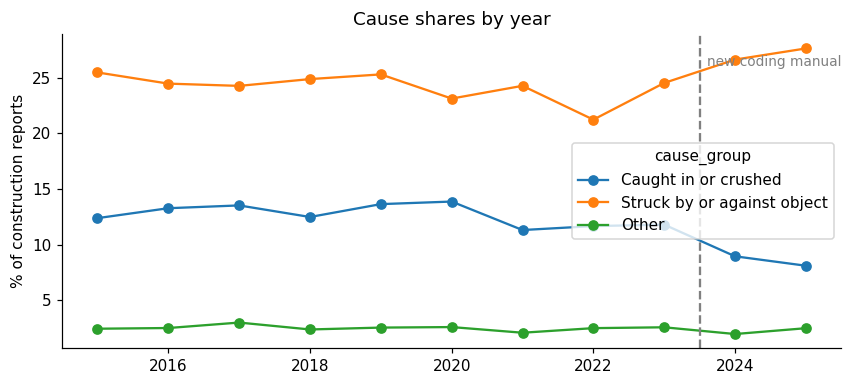

In [11]:
df['year'] = df.event_date.dt.year
old = df.EventTitle.eq('Compressed or pinched by shifting objects or equipment')
new = df.EventTitle.isin(['Caught or wedged between objects nonrunning', 'Caught, entangled in running powered equipment normal operation'])
print('Last report with the old title :', df[old].event_date.max().strftime('%b %Y'), f'({old.sum()} reports in total)')
print('First report with the new titles:', df[new].event_date.min().strftime('%b %Y'))
share = pd.crosstab(df.year, df.cause_group, normalize='index') * 100
ax = share[['Caught in or crushed', 'Struck by or against object', 'Other']].plot(marker='o', figsize=(8, 3.6))
ax.axvline(2023.5, color='grey', ls='--'); ax.text(2023.6, ax.get_ylim()[1] * .9, 'new coding manual', fontsize=9, color='grey')
ax.set_ylabel('% of construction reports'); ax.set_xlabel(''); ax.set_title('Cause shares by year'); plt.tight_layout(); plt.show()

In [12]:
pinch = df.narrative.str.lower().str.contains('pinch|caught between|crushed between')
print('Titles given to "pinched / caught between" narratives')
pd.concat({'2015-2022': df[pinch & (df.year <= 2022)].EventTitle.value_counts(normalize=True).head(5),
           '2024-2025': df[pinch & (df.year >= 2024)].EventTitle.value_counts(normalize=True).head(5)}).mul(100).round(1).to_frame('% of those narratives')

Titles given to "pinched / caught between" narratives


% of those narratives
          EventTitle                                                                                      
2015-2022 Compressed or pinched by shifting objects or equipment                                      49.2
          Caught in running equipment or machinery during regular operation                            7.5
          Caught in or compressed by equipment or objects, unspecified                                 7.4
          Struck by swinging part of powered vehicle                                                   3.6
          Injured by slipping or swinging object held by injured worker                                3.3
2024-2025 Caught or wedged between objects nonrunning                                                 22.0
          Caught, entangled in running powered equipment normal operation                             10.5
          Struck by suspended or swinging objects n.e.c.                                               9.0
          Compressed between running equipment and other object(s)                                     5.4
          Struck by running powered equipment during maintenance, cleaning, testing                    5.4

The same kind of accident is now coded differently: a hand pinched between objects used to be "Compressed or pinched by shifting objects", and is now often "Caught or wedged between objects" or a struck-by code. **This matters for modelling:** a model trained on 2015–2022 labels is tested on 2024–2025 labels written under different rules. It is a real example of *label drift*, and notebook 2 measures its cost. The time split in this project is therefore:

| Split | Years | Coding manual |
|---|---|---|
| Train | 2015–2022 | old |
| Validation (tuning) | 2023 | old |
| Test | 2024 – Nov 2025 | new |

In [13]:
df.groupby('split').agg(reports=('ID', 'size'), first=('event_date', 'min'), last=('event_date', 'max')).loc[['train', 'validation', 'test']]

,reports,first,last
split,,,
train,14138,2015-01-02,2022-12-30
validation,1626,2023-01-02,2023-12-29
test,3257,2024-01-02,2025-11-28


## 8. Exploratory risk analysis
Before any model, the data already answers the safety manager's first question: where are the serious injuries?

In [14]:
known = df[df.cause_group != C.UNKNOWN]
risk = known.groupby('cause_group').agg(reports=('ID', 'size'), workers_amputation=('Amputation', 'sum'), workers_hospitalised=('Hospitalized', 'sum'))
risk['amputation rate %'] = (known.groupby('cause_group').Amputation.apply(lambda s: (s > 0).mean()) * 100).round(1)
risk = risk.sort_values('reports', ascending=False); risk

,reports,workers_amputation,workers_hospitalised,amputation rate %
cause_group,,,,
Fall to lower level,6806,27,6860,0.4
Struck by or against object,4706,1166,3925,24.8
Caught in or crushed,2285,1437,1254,62.8
Vehicle or mobile equipment,1429,96,1408,6.7
Electrical,959,22,1009,2.3
"Slip, trip or same-level fall",881,24,861,2.7
Heat stress,605,0,606,0.0
"Fire, explosion or burn",497,8,528,1.6
Other,472,0,486,0.0


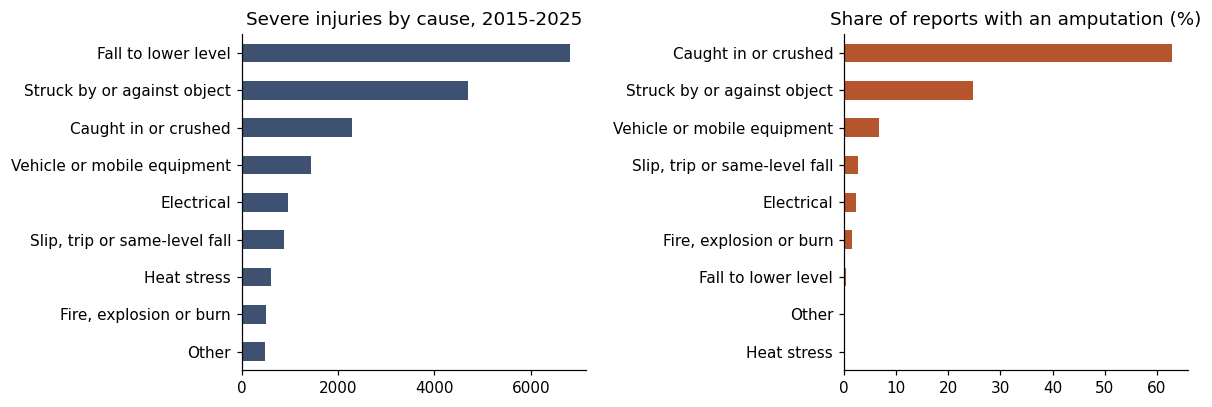

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
risk.reports.sort_values().plot.barh(ax=ax[0], color='#3F5170'); ax[0].set_title('Severe injuries by cause, 2015-2025'); ax[0].set_ylabel('')
risk['amputation rate %'].sort_values().plot.barh(ax=ax[1], color='#B4552E'); ax[1].set_title('Share of reports with an amputation (%)'); ax[1].set_ylabel('')
plt.tight_layout(); plt.show()

Falls to a lower level are by far the most common severe injury, but they rarely cause amputations. **Caught-in/crushed accidents are the amputation hazard**: fingers and hands caught in machinery or pinched between loads. That points to different controls: fall protection for the first, machine guarding and hand-safety for the second.

In [16]:
top_trades = known.trade.value_counts().head(6).index
tt = pd.crosstab(known[known.trade.isin(top_trades)].trade, known.cause_group, normalize='index').mul(100).round(0)
tt[risk.index[:6]]

cause_group,Fall to lower level,Struck by or against object,Caught in or crushed,Vehicle or mobile equipment,Electrical,"Slip, trip or same-level fall"
trade,,,,,,
"Building equipment (electrical, plumbing, HVAC)",38.0,19.0,11.0,4.0,15.0,5.0
"Foundation, structure and exterior (incl. roofing, framing, concrete, steel)",54.0,22.0,9.0,4.0,1.0,4.0
"Highway, street and bridge",13.0,26.0,16.0,24.0,2.0,5.0
Non-residential building,32.0,30.0,15.0,7.0,2.0,6.0
"Other specialty trades (site prep, demolition)",24.0,30.0,15.0,12.0,2.0,6.0
Utility systems,15.0,31.0,18.0,10.0,10.0,4.0


The hazard mix changes by trade. Foundation, structure and roofing contractors are dominated by falls; utility contractors (trenching, pipelines) have far more struck-by and caught-in injuries; building equipment contractors (electrical, plumbing, HVAC) account for 57% of all electrical injuries.

3,643 falls have a height band in the OSHA title (54% of falls)


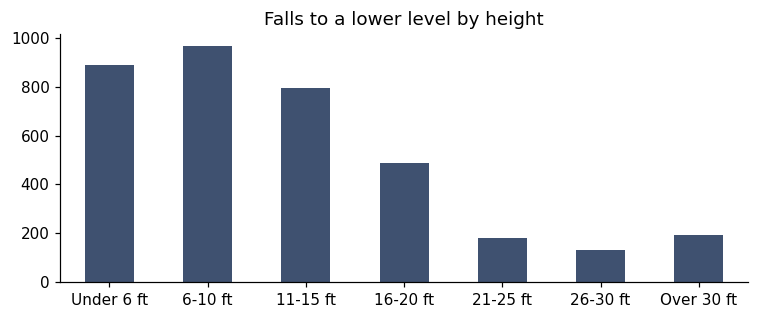

In [17]:
falls = known[known.fall_band_osha != '']
order = ['Under 6 ft', '6-10 ft', '11-15 ft', '16-20 ft', '21-25 ft', '26-30 ft', 'Over 30 ft']
fb = falls.fall_band_osha.value_counts().reindex(order).dropna()
print(f'{len(falls):,} falls have a height band in the OSHA title ({len(falls)/(known.cause_group=="Fall to lower level").sum():.0%} of falls)')
ax = fb.plot.bar(color='#3F5170', figsize=(7, 3)); ax.set_title('Falls to a lower level by height'); ax.set_xlabel(''); plt.xticks(rotation=0); plt.tight_layout(); plt.show()

About one in four banded falls (24%) is from **under 6 feet**, a height at which many workers don't think fall protection is needed. Ladders and low platforms are a real hazard, not only roofs and steelwork.

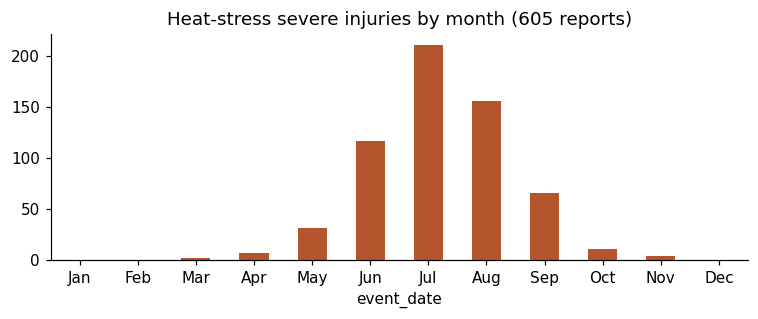

Top states for heat stress: {'Texas': 157, 'Florida': 141, 'Pennsylvania': 31, 'Georgia': 27, 'Arkansas': 25}


In [18]:
heat = known[known.cause_group == 'Heat stress']
ax = heat.event_date.dt.month.value_counts().reindex(range(1, 13), fill_value=0).plot.bar(color='#B4552E', figsize=(7, 3))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], rotation=0)
ax.set_title(f'Heat-stress severe injuries by month ({len(heat)} reports)'); plt.tight_layout(); plt.show()
print('Top states for heat stress:', heat.state.value_counts().head(5).to_dict())

In [19]:
print('Body parts most often injured, by cause (top 2):')
known.groupby('cause_group')['Part of Body Title'].agg(lambda s: ', '.join(f'{k} ({v})' for k, v in s.value_counts().head(2).items()))

Body parts most often injured, by cause (top 2):


cause_group
Caught in or crushed                           Fingertip(s) (572), Finger(s), fingernail(s), n.e.c. (483)
Electrical                                          BODY SYSTEMS (252), Multiple body parts, n.e.c. (142)
Fall to lower level                              Multiple body parts, n.e.c. (884), Nonclassifiable (576)
Fire, explosion or burn                           Multiple body parts, n.e.c. (133), Nonclassifiable (56)
Heat stress                                                                 BODY SYSTEMS (600), Heart (3)
Other                            BODY SYSTEMS (142), Back, including spine, spinal cord, unspecified (28)
Slip, trip or same-level fall                                                  Hip(s) (72), Ankle(s) (68)
Struck by or against object                    Finger(s), fingernail(s), n.e.c. (381), Fingertip(s) (351)
Vehicle or mobile equipment                  Leg(s), unspecified (149), Multiple body parts, n.e.c. (120)
Name: Part of Body Title, dtype: s

## 9. Save the clean dataset
The saved file has one row per construction report, with no employer names, addresses or coordinates. It is what notebooks 2 and 3 and the app use.

In [20]:
final = C.final_table(df)
final.to_csv('../data/osha_construction_clean.csv', index=False)
cmap.to_csv('../data/cause_group_map.csv', index=False)
rep = C.quality_report(raw, con, final)
with open('../reports/data_quality.json', 'w') as f: json.dump(rep, f, indent=2, default=str)
print(f'Saved {len(final):,} rows and {final.shape[1]} columns'); final.columns.tolist()

Saved 19,021 rows and 26 columns


['report_id',
 'event_date',
 'split',
 'state',
 'naics',
 'naics4',
 'trade',
 'narrative',
 'employer_redacted',
 'hospitalised',
 'amputations',
 'loss_of_eye',
 'severity',
 'inspected',
 'event_code',
 'event_title',
 'cause_group',
 'fall_band_osha',
 'nature_code',
 'nature',
 'body_part_code',
 'body_part',
 'source_code',
 'source',
 'secondary_source_code',
 'secondary_source']

## Summary
- **Data:** 19,021 construction severe injury reports from 2015 to November 2025, out of 105,996 across all industries. Zero bad dates, 3 duplicate narratives, 22 very short narratives, and 381 reports with no usable cause.
- **Cleaning:** kept construction by NAICS 23, fixed types, trimmed text, removed employer names and addresses, and grouped 348 inconsistent event codes into nine cause groups using the titles.
- **Finding:** OSHA changed its coding manual in January 2024, so the same accident can get a different label before and after. The test set (2024–2025) is deliberately on the new manual, to measure how a model copes.
- **Risk picture:** falls are the most frequent severe injury; caught-in/crushed accidents cause the most amputations; the hazard mix differs sharply by trade; 80% of heat injuries happen from June to August, mostly in Texas and Florida.